In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold
%matplotlib inline

In [4]:
# Load the dataset
df = pd.read_csv('ai_job_market.csv')  # Replace with your file path

# Display dataset info
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (2000, 12)

First 5 Rows:


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [14]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
job_id              0
company_name        0
industry            0
job_title           0
skills_required     0
experience_level    0
employment_type     0
location            0
salary_range_usd    0
posted_date         0
company_size        0
tools_preferred     0
salary_numeric      0
is_high_salary      0
skill_count         0
dtype: int64


## Assignment #1: EDA

### Descriptive Statistics

In [19]:
print("Dataset Overview:")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1] - 1}")

Dataset Overview:
Total Samples: 2000
Total Features: 14


In [21]:
print("Feature Summary:")
print(df.describe())

Feature Summary:
            job_id  salary_numeric  is_high_salary  skill_count
count  2000.000000     2000.000000     2000.000000  2000.000000
mean   1000.500000   123040.001500        0.500000     4.489000
std     577.494589    34776.200983        0.500125     1.126727
min       1.000000    47578.500000        0.000000     3.000000
25%     500.750000    94466.250000        0.000000     3.000000
50%    1000.500000   123202.750000        0.500000     4.000000
75%    1500.250000   151413.000000        1.000000     6.000000
max    2000.000000   197776.500000        1.000000     6.000000


In [10]:
# Function to convert '123-456' string to the average number
def clean_salary(salary_str):
    if '-' in str(salary_str):
        low, high = salary_str.split('-')
        return (int(low) + int(high)) / 2
    return None

df['salary_numeric'] = df['salary_range_usd'].apply(clean_salary)

median_val = df['salary_numeric'].median()
df['is_high_salary'] = (df['salary_numeric'] > median_val).astype(int)

print(f"Median Salary for Classification: ${median_val:,.2f}")

Median Salary for Classification: $123,202.75


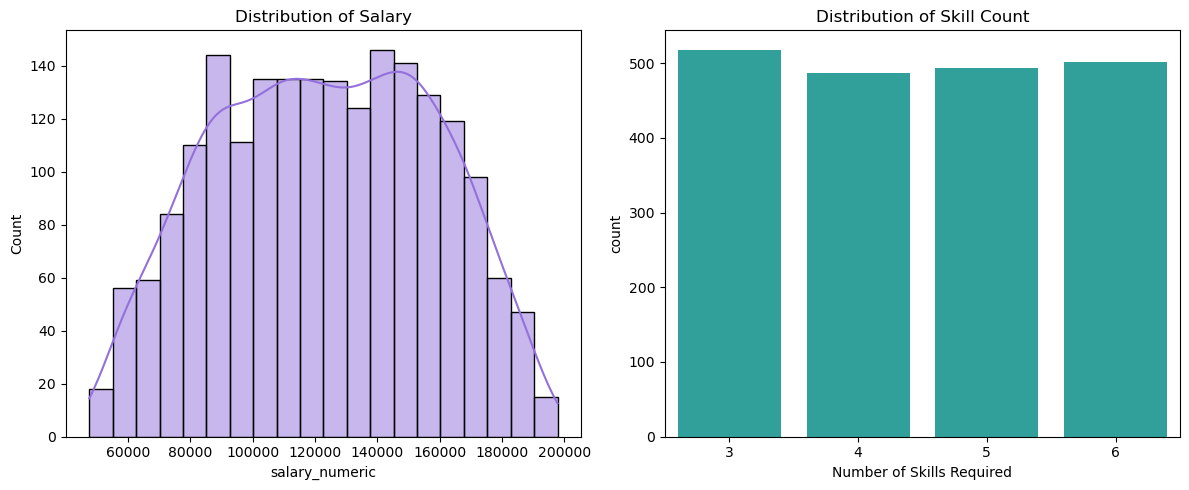

In [25]:
# Create a 'skill_count' feature first to have another number to plot
df['skill_count'] = df['skills_required'].apply(lambda x: len(str(x).split(',')))

num_cols = ['salary_numeric', 'skill_count']
colors = ['mediumpurple', 'lightseagreen']

plt.figure(figsize=(12, 5))

# Salary distribution
plt.subplot(1,2,1)
sns.histplot(df['salary_numeric'], bins=20, kde=True,
             color='mediumpurple', edgecolor='black')
plt.title('Distribution of Salary')

# Skill count distribution
plt.subplot(1,2,2)
sns.countplot(x='skill_count', data=df, color='lightseagreen')
plt.title('Distribution of Skill Count')
plt.xlabel('Number of Skills Required')

plt.tight_layout()
plt.show()

The salary distribution suggests AI roles offer relatively high compensation with substantial variation, likely reflecting differences in experience, specialization, and employer demand. Salaries appear concentrated in mid-to-upper pay bands, supporting evidence of strong market demand for AI talent. The skill count distribution shows most roles require between three and six skills, with relatively even frequencies across categories, suggesting employers consistently value candidates with broad but manageable technical skill sets rather than extreme specialization. Together, these patterns indicate an AI job market characterized by both strong compensation opportunities and demand for diversified technical capabilities.

/var/folders/5w/dnk1dd6j7pdgwmjq4_g6c84c0000gn/T/ipykernel_24393/4107749501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_high_salary', palette='magma', edgecolor='black', errorbar=None)
/var/folders/5w/dnk1dd6j7pdgwmjq4_g6c84c0000gn/T/ipykernel_24393/4107749501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='is_high_salary', palette='magma', edgecolor='black', errorbar=None)
/var/folders/5w/dnk1dd6j7pdgwmjq4_g6c84c0000gn/T/ipykernel_24393/4107749501.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



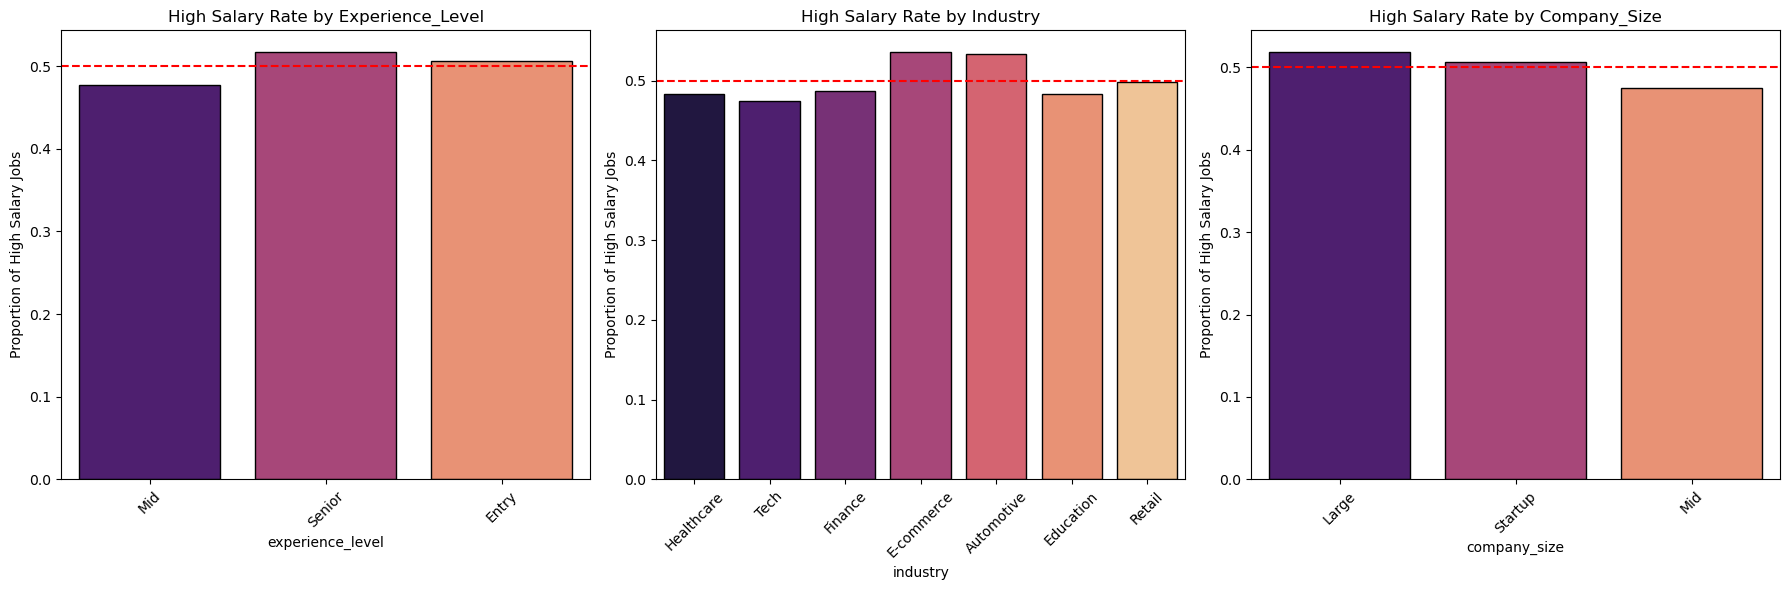

In [28]:
# List of categorical features to explore
cat_features = ['experience_level', 'industry', 'company_size']

plt.figure(figsize=(18, 6))

for i, col in enumerate(cat_features, 1):
    plt.subplot(1, 3, i)
    
    # We plot the 'High Salary Rate' (mean of is_high_salary)
    # This shows the percentage of jobs in that category that pay above the median
    sns.barplot(data=df, x=col, y='is_high_salary', palette='magma', edgecolor='black', errorbar=None)
    
    plt.axhline(y=0.5, color='red', linestyle='--', label='Overall Avg')
    plt.title(f'High Salary Rate by {col.title()}')
    plt.ylabel('Proportion of High Salary Jobs')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The analysis suggests the proportion of high-salary AI roles varies modestly across experience levels, industries, and company size. Senior roles show the highest concentration of high-paying opportunities, although entry-level roles also appear competitive, potentially reflecting strong early-career demand for AI talent. Across industries, sectors such as e-commerce and automotive show relatively higher shares of high-salary roles, suggesting strong compensation opportunities in AI-intensive sectors beyond traditional technology firms. By company size, large firms and startups appear to offer a greater proportion of high-paying roles than mid-sized firms. Overall, the results indicate that compensation opportunities in the AI job market may be shaped not only by experience, but also by sector and organisational characteristics.

In [67]:
df_ml = df.copy()

# Drop columns
cols_to_drop = [
    'job_id', 'company_name', 'location', 'salary_range_usd', 
    'salary_numeric', 'posted_date', 'skills_required'
]
df_ml = df_ml.drop(columns=cols_to_drop)

# One-Hot Encoding 
df_final = pd.get_dummies(df_ml, drop_first=True)

In [69]:
X = df_final.drop('is_high_salary', axis=1)
y = df_final['is_high_salary']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression Performance:")
print(classification_report(y_test, model.predict(X_test_scaled)))

Baseline Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.49      0.52      0.50       201
           1       0.48      0.45      0.47       199

    accuracy                           0.48       400
   macro avg       0.48      0.48      0.48       400
weighted avg       0.48      0.48      0.48       400

